# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = "IT5006/Project/data"

# Create Master Table

## Read Tables

In [ ]:
orders = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv",
                           parse_dates=["order_purchase_timestamp", "order_approved_at",
                                        "order_delivered_carrier_date",
                                        "order_delivered_customer_date",
                                        "order_estimated_delivery_date"])
items = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv",
                           parse_dates=["shipping_limit_date"])
payments = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv",
                           parse_dates=["review_creation_date", "review_answer_timestamp"])
customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
sellers = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
geolocation = pd.read_csv(f"{DATA_DIR}/olist_geolocation_dataset.csv")
cat_trans = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

tables = {
    "orders": orders, "items": items, "payments": payments, "reviews": reviews,
    "customers": customers, "sellers": sellers, "products": products,
    "geolocation": geolocation, "category_translation": cat_trans
}
for name, df in tables.items():
    print(f"{name:22s} shape={df.shape}")

orders                 shape=(99441, 8)
items                  shape=(112650, 7)
payments               shape=(103886, 5)
reviews                shape=(99224, 7)
customers              shape=(99441, 5)
sellers                shape=(3095, 4)
products               shape=(32951, 9)
geolocation            shape=(1000163, 5)
category_translation   shape=(71, 2)


## Merge Data

In [ ]:
# 2a. Collapse order_items to order grain
items_agg = (items.groupby("order_id")
             .agg(n_items=("order_item_id", "count"),
                  item_price_total=("price", "sum"),
                  freight_total=("freight_value", "sum"),
                  n_distinct_products=("product_id", "nunique"),
                  n_distinct_sellers=("seller_id", "nunique"))
             .reset_index())

# 2b. Collapse payments to order grain
pay_agg = (payments.groupby("order_id")
           .agg(payment_value_total=("payment_value", "sum"),
                n_payment_rows=("payment_sequential", "count"),
                max_installments=("payment_installments", "max"))
           .reset_index())
pay_type = (payments.sort_values("payment_value", ascending=False)
            .drop_duplicates("order_id")[["order_id", "payment_type"]]
            .rename(columns={"payment_type": "primary_payment_type"}))

# 2c. Reviews — keep most recent review per order
reviews_dedup = (reviews.sort_values("review_creation_date")
                  .drop_duplicates("order_id", keep="last")
                  [["order_id", "review_score", "review_creation_date",
                    "review_comment_message"]])

# 2d. Product category in English
products_en = products.merge(cat_trans, on="product_category_name", how="left")
products_en["product_category_name_english"] = (
    products_en["product_category_name_english"]
    .fillna(products_en["product_category_name"]))

# Get a single representative category per order (category of most expensive item)
item_cat = (items.merge(products_en[["product_id", "product_category_name_english"]],
                         on="product_id", how="left")
            .sort_values("price", ascending=False)
            .drop_duplicates("order_id")
            [["order_id", "product_category_name_english"]])

# 2e. Customer state/city
cust_small = customers[["customer_id", "customer_city", "customer_state"]]

# 2f. Master order-level table
df = (orders
      .merge(cust_small, on="customer_id", how="left")
      .merge(items_agg, on="order_id", how="left")
      .merge(pay_agg, on="order_id", how="left")
      .merge(pay_type, on="order_id", how="left")
      .merge(reviews_dedup, on="order_id", how="left")
      .merge(item_cat, on="order_id", how="left"))

df["order_total_value"] = df["item_price_total"].fillna(0) + df["freight_total"].fillna(0)

# Derived time features
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["purchase_dow"] = df["order_purchase_timestamp"].dt.day_name()
df["purchase_hour"]  = df["order_purchase_timestamp"].dt.hour

# Delivery performance (only meaningful for delivered orders)
df["delivery_days"] = (df["order_delivered_customer_date"]
                        - df["order_purchase_timestamp"]).dt.days
df["estimated_days"] = (df["order_estimated_delivery_date"]
                         - df["order_purchase_timestamp"]).dt.days
df["delivery_delta_vs_estimate"] = (df["order_delivered_customer_date"]
                                     - df["order_estimated_delivery_date"]).dt.days
df["is_late"] = df["delivery_delta_vs_estimate"] > 0

print(df.shape)
df.head()

(99441, 32)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,n_items,item_price_total,freight_total,n_distinct_products,n_distinct_sellers,payment_value_total,n_payment_rows,max_installments,primary_payment_type,review_score,review_creation_date,review_comment_message,product_category_name_english,order_total_value,purchase_year,purchase_month,purchase_dow,purchase_hour,delivery_days,estimated_days,delivery_delta_vs_estimate,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,1.00,29.99,8.72,1.00,1.00,38.71,3.00,1.00,voucher,4.00,2017-10-11,"Não testei o produto ainda, mas ele veio corre...",housewares,38.71,2017,2017-10,Monday,10,8.00,15,-8.00,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,1.00,118.70,22.76,1.00,1.00,141.46,1.00,1.00,boleto,4.00,2018-08-08,Muito bom o produto.,perfumery,141.46,2018,2018-07,Tuesday,20,13.00,19,-6.00,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,1.00,159.90,19.22,1.00,1.00,179.12,1.00,3.00,credit_card,5.00,2018-08-18,NaN,auto,179.12,2018,2018-08,Wednesday,8,9.00,26,-18.00,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,1.00,45.00,27.20,1.00,1.00,72.20,1.00,1.00,credit_card,5.00,2017-12-03,O produto foi exatamente o que eu esperava e e...,pet_shop,72.20,2017,2017-11,Saturday,19,13.00,26,-13.00,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,1.00,19.90,8.72,1.00,1.00,28.62,1.00,1.00,credit_card,5.00,2018-02-17,NaN,stationery,28.62,2018,2018-02,Tuesday,21,2.00,12,-10.00,False


## Data Quality Checks

In [ ]:
print("Order status distribution:")
print(orders["order_status"].value_counts(normalize=True).mul(100).round(1))

missing = df.isna().mean().sort_values(ascending=False).mul(100).round(2)
print("\nTop columns by % missing:")
print(missing[missing > 0].head(10))

dup_orders = df["order_id"].duplicated().sum()
print(f"\nDuplicate order_id rows in master table: {dup_orders}")

Order status distribution:
order_status
delivered     97.00
shipped        1.10
canceled       0.60
unavailable    0.60
invoiced       0.30
processing     0.30
created        0.00
approved       0.00
Name: proportion, dtype: float64

Top columns by % missing:
review_comment_message          58.99
order_delivered_customer_date    2.98
delivery_delta_vs_estimate       2.98
delivery_days                    2.98
product_category_name_english    2.21
order_delivered_carrier_date     1.79
n_items                          0.78
n_distinct_sellers               0.78
freight_total                    0.78
n_distinct_products              0.78
dtype: float64

Duplicate order_id rows in master table: 0


# Univariate Analysis

## Order Status Distribution

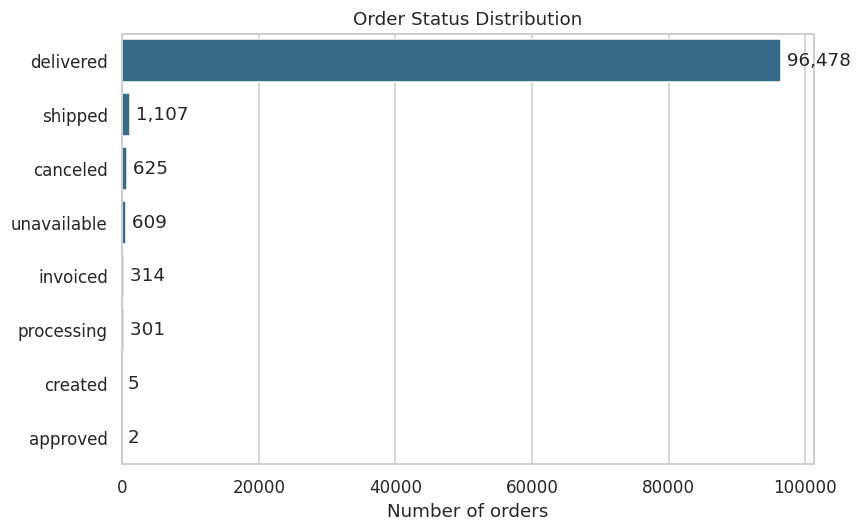

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
order_status_counts = orders["order_status"].value_counts()
sns.barplot(x=order_status_counts.values, y=order_status_counts.index, ax=ax, color="#2A6F97")
ax.set_xlabel("Number of orders")
ax.set_ylabel("")
ax.set_title("Order Status Distribution")
for i, v in enumerate(order_status_counts.values):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.show()

## Payment Type

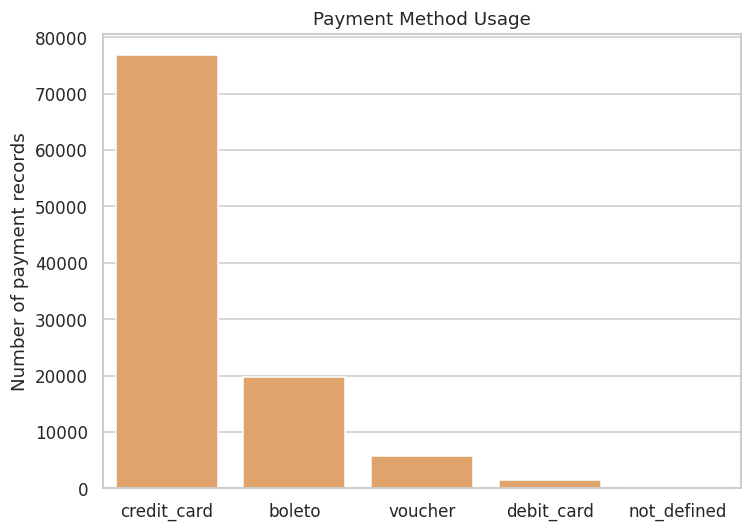

Installments distribution (credit card):
count   76,795.00
mean         3.51
std          2.85
min          0.00
25%          1.00
50%          3.00
75%          5.00
max         24.00
Name: payment_installments, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
pay_counts = payments["payment_type"].value_counts()
sns.barplot(x=pay_counts.index, y=pay_counts.values, ax=ax, color="#F4A259")
ax.set_ylabel("Number of payment records")
ax.set_xlabel("")
ax.set_title("Payment Method Usage")
plt.tight_layout()
plt.show()

print("Installments distribution (credit card):")
cc = payments[payments.payment_type == "credit_card"]
print(cc["payment_installments"].describe())

## Review Score

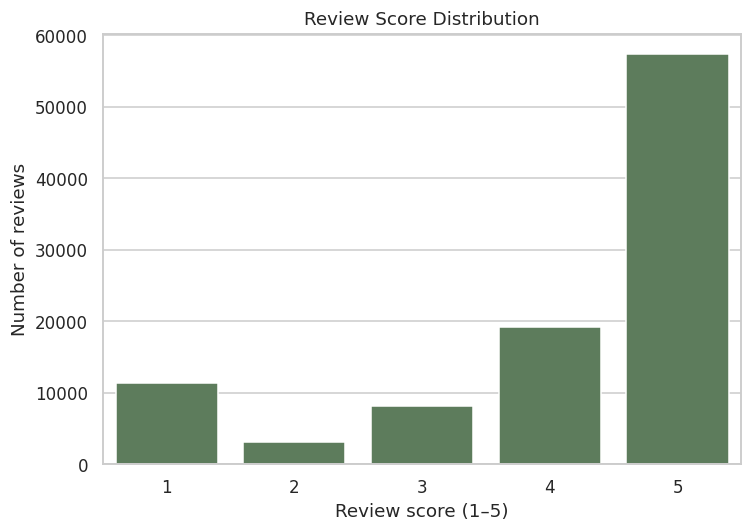

5-star share: 57.8% | 1-star share: 11.5%


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
review_counts = reviews["review_score"].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, ax=ax, color="#588157")
ax.set_xlabel("Review score (1–5)")
ax.set_ylabel("Number of reviews")
ax.set_title("Review Score Distribution")
plt.tight_layout()
plt.show()

pct_5 = (reviews.review_score == 5).mean() * 100
pct_1 = (reviews.review_score == 1).mean() * 100
print(f"5-star share: {pct_5:.1f}% | 1-star share: {pct_1:.1f}%")

# Time Series Analysis

## Order Volume and Revenue Trends

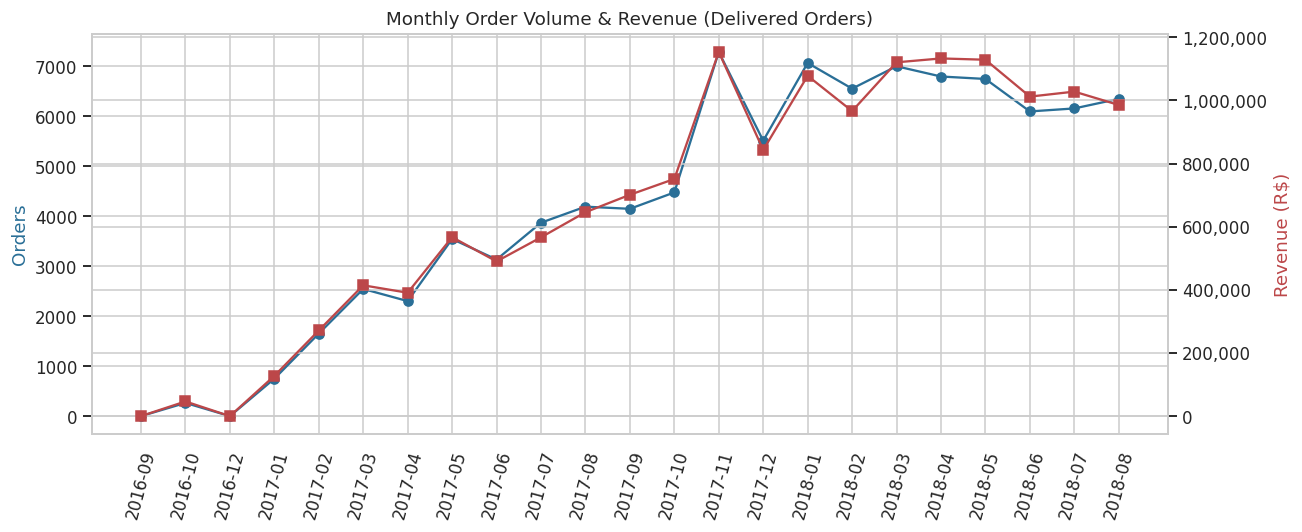

In [ ]:
delivered = df[df.order_status == "delivered"].copy()

monthly = (delivered.groupby("purchase_month")
           .agg(orders=("order_id", "nunique"),
                revenue=("order_total_value", "sum"))
           .reset_index())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["purchase_month"], monthly["orders"], marker="o", color="#2A6F97", label="Orders")
ax1.set_ylabel("Orders", color="#2A6F97")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()
ax2.plot(monthly["purchase_month"], monthly["revenue"], marker="s", color="#BC4749", label="Revenue (R$)")
ax2.set_ylabel("Revenue (R$)", color="#BC4749")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax1.set_title("Monthly Order Volume & Revenue (Delivered Orders)")
fig.tight_layout()
plt.show()

## Order Volume by Day of Week and Hour of Day

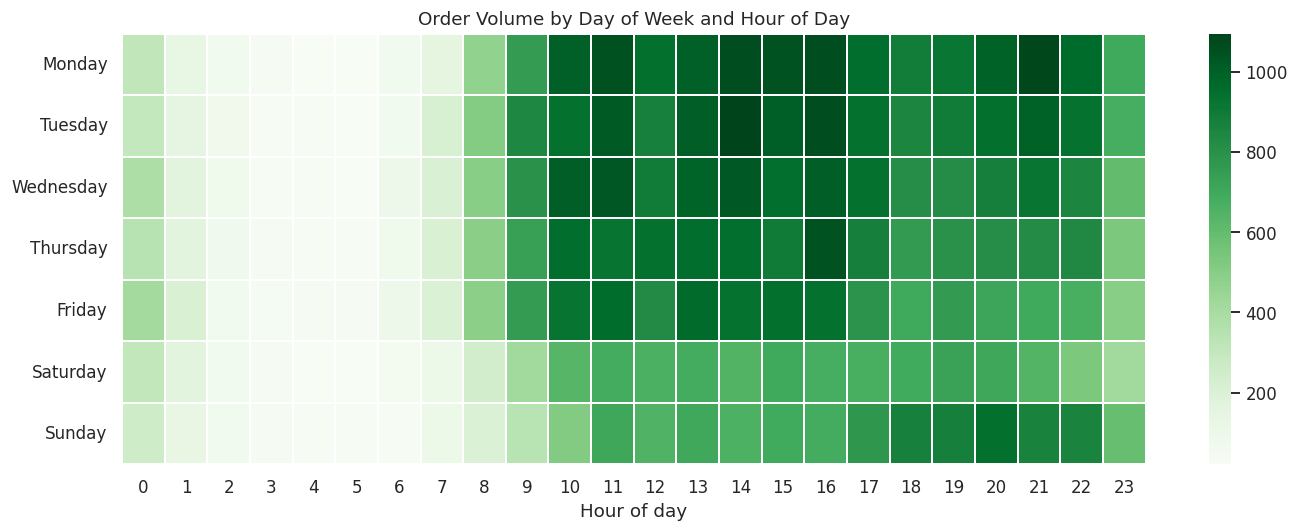

In [ ]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (delivered.groupby(["purchase_dow", "purchase_hour"])
        .size().reset_index(name="orders")
        .pivot(index="purchase_dow", columns="purchase_hour", values="orders")
        .reindex(dow_order))

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heat, cmap="Greens", ax=ax, linewidths=0.3)
ax.set_title("Order Volume by Day of Week and Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Delivery Performance

## Delivery Time Distribution

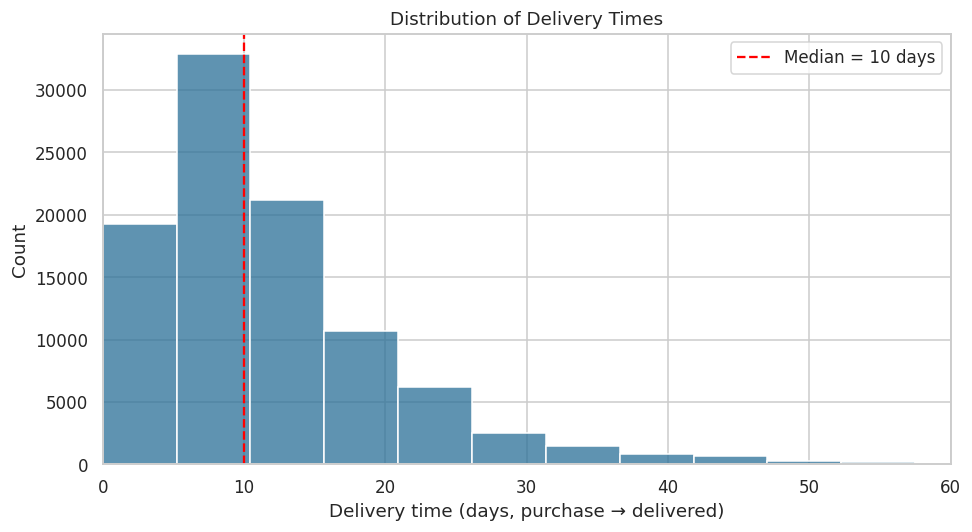

count   96,470.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_days, dtype: float64
Share of orders delivered later than the estimated date: 6.8%


In [ ]:
deliv = delivered.dropna(subset=["delivery_days"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(deliv["delivery_days"], bins=40, ax=ax, color="#2A6F97")
ax.axvline(deliv["delivery_days"].median(), color="red", linestyle="--",
           label=f"Median = {deliv['delivery_days'].median():.0f} days")
ax.set_xlabel("Delivery time (days, purchase → delivered)")
ax.set_title("Distribution of Delivery Times")
ax.legend()
ax.set_xlim(0, 60)
plt.tight_layout()
plt.show()

print(deliv["delivery_days"].describe())
late_rate = deliv["is_late"].mean() * 100
print(f"Share of orders delivered later than the estimated date: {late_rate:.1f}%")

## Delivery Time by State

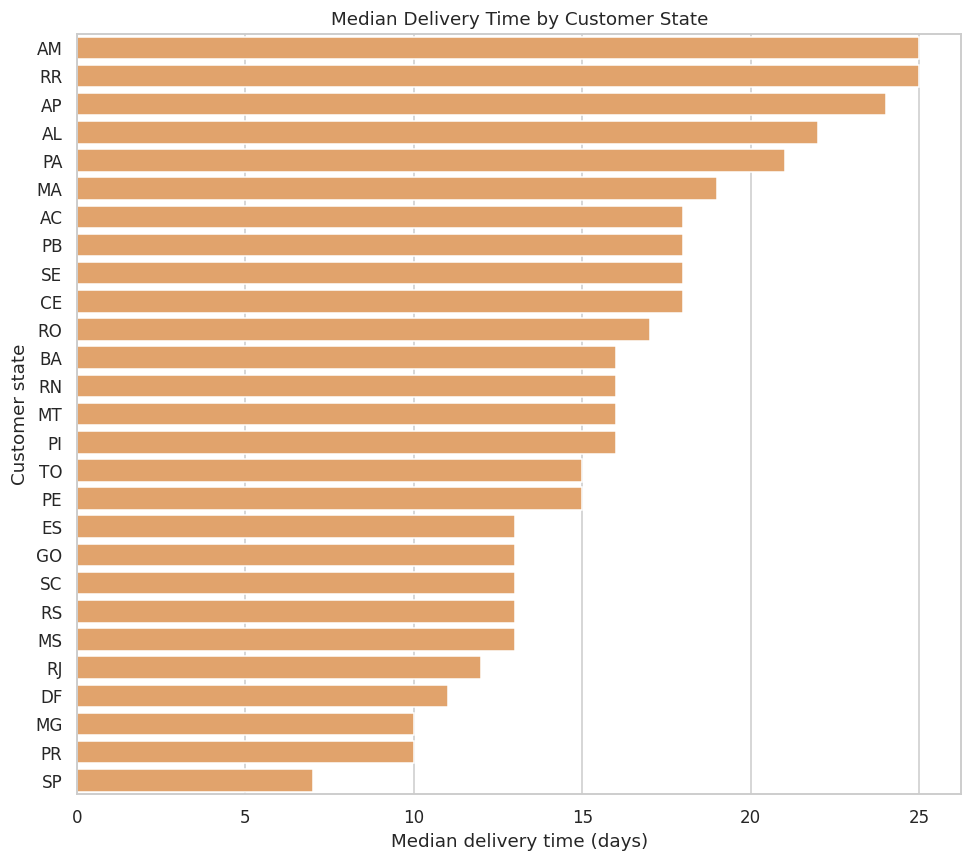

In [ ]:
state_delivery = (deliv.groupby("customer_state")["delivery_days"]
                   .median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=state_delivery.values, y=state_delivery.index, ax=ax, color="#F4A259")
ax.set_xlabel("Median delivery time (days)")
ax.set_ylabel("Customer state")
ax.set_title("Median Delivery Time by Customer State")
plt.tight_layout()
plt.show()

## Delivery Time vs Review Score

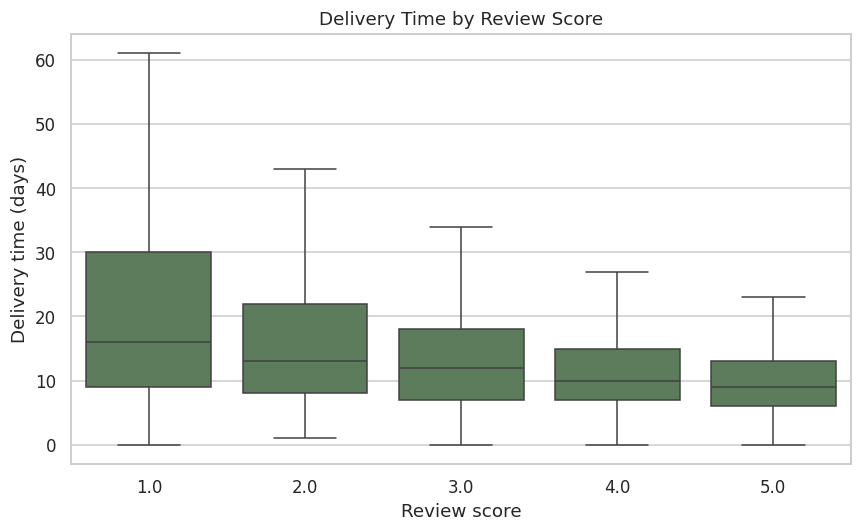

Average review score, on-time vs late deliveries:
is_late
False   4.29
True    2.27
Name: review_score, dtype: float64
Correlation (delivery_days, review_score): -0.334


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=deliv.dropna(subset=["review_score"]),
            x="review_score", y="delivery_days", ax=ax, color="#588157", showfliers=False)
ax.set_title("Delivery Time by Review Score")
ax.set_xlabel("Review score")
ax.set_ylabel("Delivery time (days)")
plt.tight_layout()
plt.show()

late_review = (deliv.dropna(subset=["review_score"])
               .groupby("is_late")["review_score"].mean())
print("Average review score, on-time vs late deliveries:")
print(late_review)

corr = deliv[["delivery_days", "review_score"]].corr().iloc[0, 1]
print(f"Correlation (delivery_days, review_score): {corr:.3f}")

# Revenue by Product Category and Geography

## Top Categories by Revenue

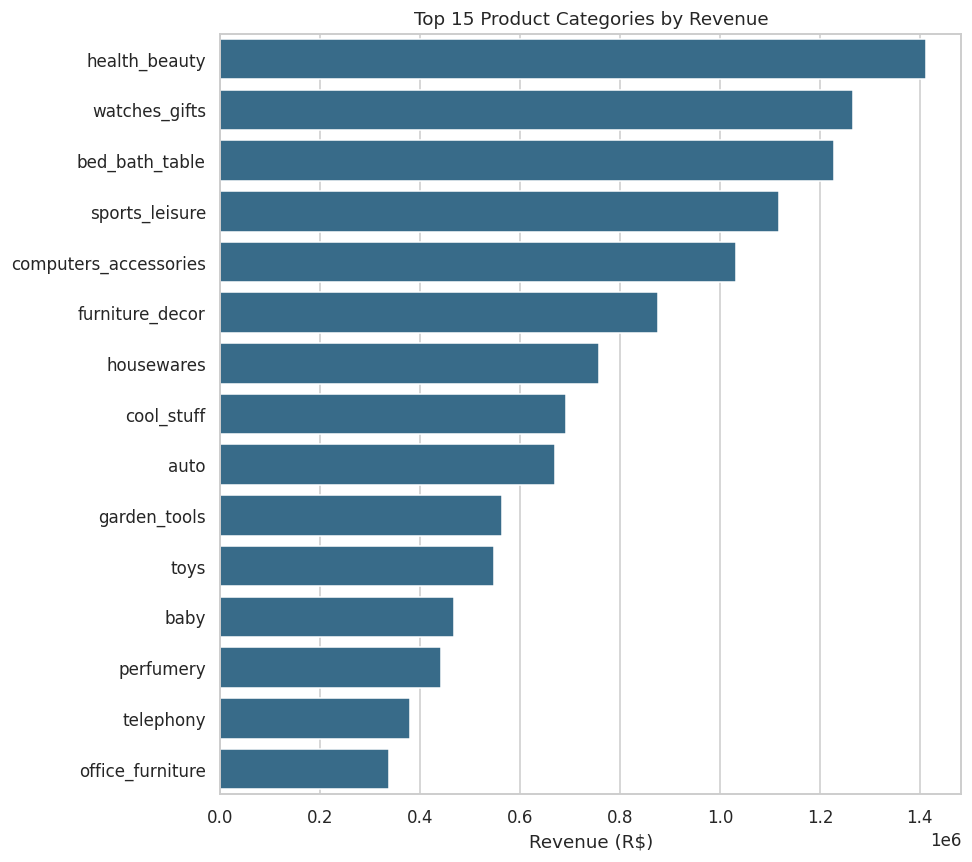

                                   revenue  orders  avg_review
product_category_name_english                                 
health_beauty                 1,412,625.21    8612        4.23
watches_gifts                 1,265,646.64    5478        4.12
bed_bath_table                1,227,315.77    9188        4.01
sports_leisure                1,117,692.21    7493        4.24
computers_accessories         1,032,733.64    6512        4.08
furniture_decor                 876,381.89    6186        4.08
housewares                      757,890.31    5680        4.20
cool_stuff                      692,050.84    3530        4.23
auto                            669,938.26    3794        4.15
garden_tools                    563,621.59    3401        4.20
toys                            548,053.67    3787        4.24
baby                            467,296.04    2758        4.12
perfumery                       442,490.74    3071        4.27
telephony                       378,580.65    4073     

In [ ]:
cat_rev = (delivered.dropna(subset=["product_category_name_english"])
           .groupby("product_category_name_english")
           .agg(revenue=("order_total_value", "sum"),
                orders=("order_id", "nunique"),
                avg_review=("review_score", "mean"))
           .sort_values("revenue", ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=cat_rev["revenue"], y=cat_rev.index, ax=ax, color="#2A6F97")
ax.set_xlabel("Revenue (R$)")
ax.set_ylabel("")
ax.set_title("Top 15 Product Categories by Revenue")
plt.tight_layout()
plt.show()

print(cat_rev)

## Revenue by State

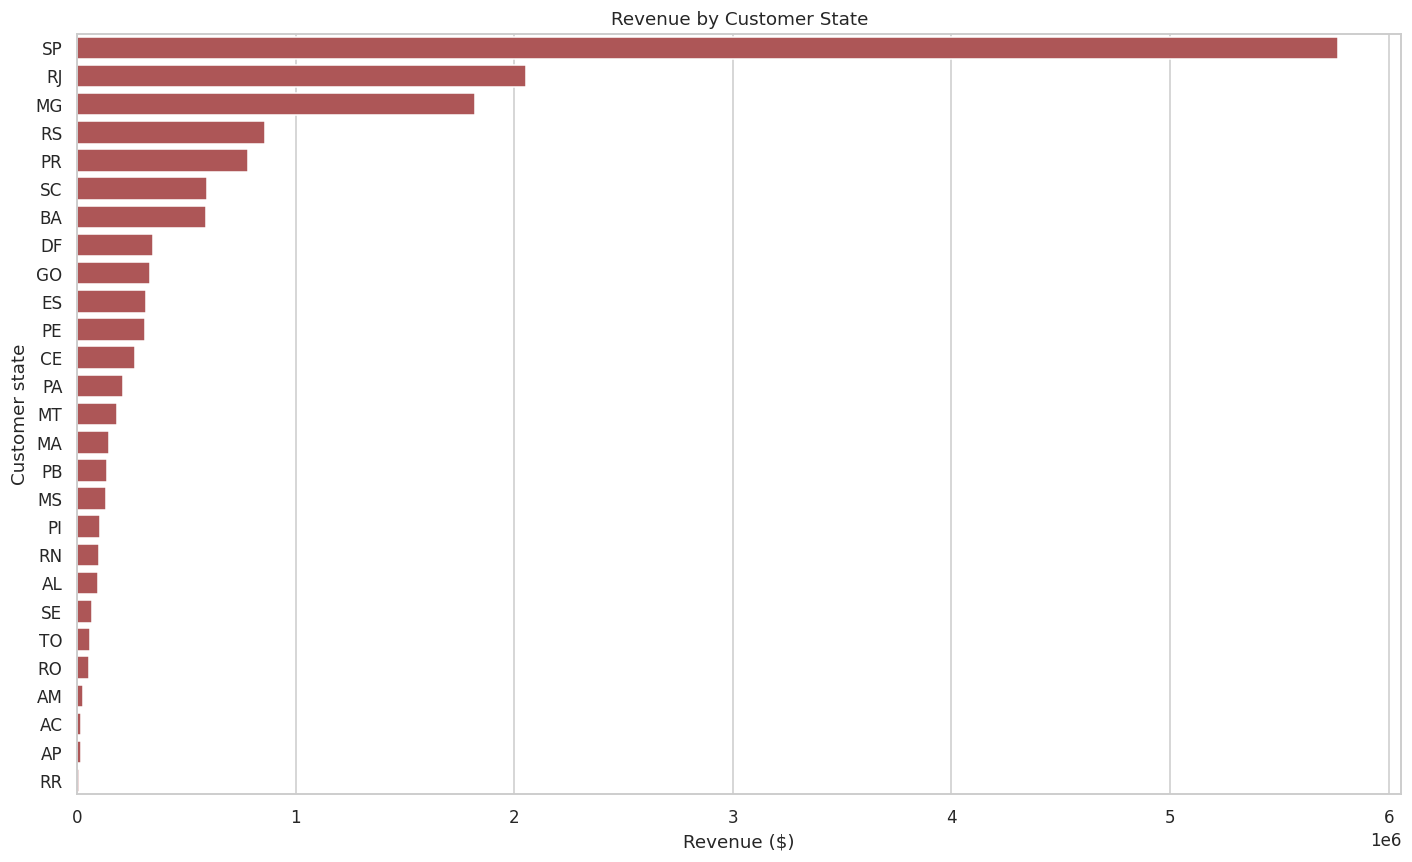

In [ ]:
state_rev = (delivered.groupby("customer_state")
             .agg(orders=("order_id", "nunique"), revenue=("order_total_value", "sum"))
             .sort_values("revenue", ascending=False))

fig, ax = plt.subplots(figsize=(13,8))
sns.barplot(x=state_rev["revenue"], y=state_rev.index, ax=ax, color="#BC4749")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Customer state")
ax.set_title("Revenue by Customer State")
plt.tight_layout()
plt.show()

# Order Value / Freight Analysis

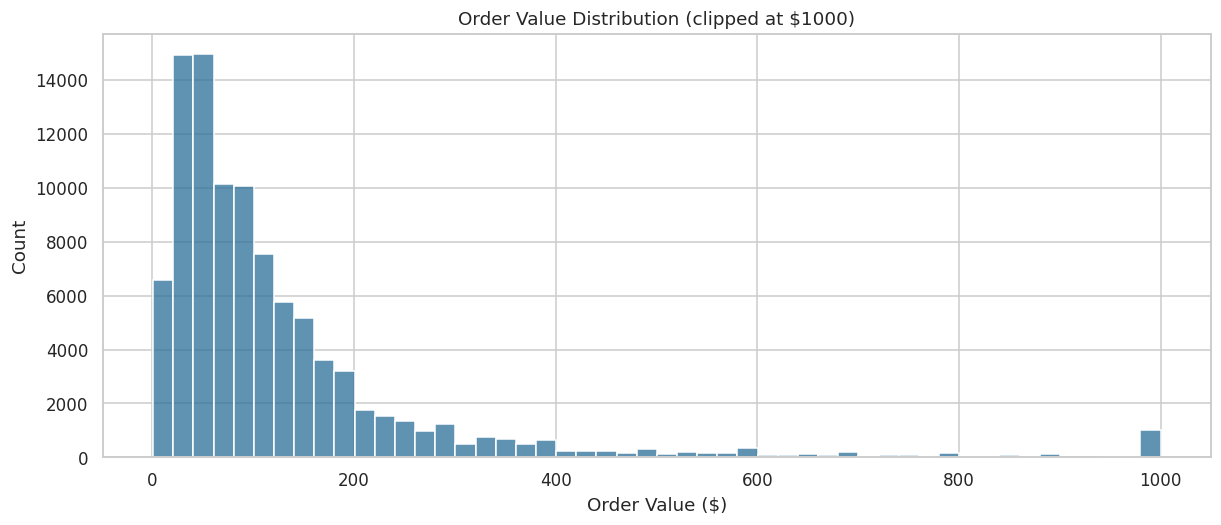

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.histplot(delivered["item_price_total"].clip(upper=1000), bins=50, ax=ax, color="#2A6F97")
ax.set_title("Order Value Distribution (clipped at $1000)")
ax.set_xlabel("Order Value ($)")
plt.show()

## Freight Ratio Distribution

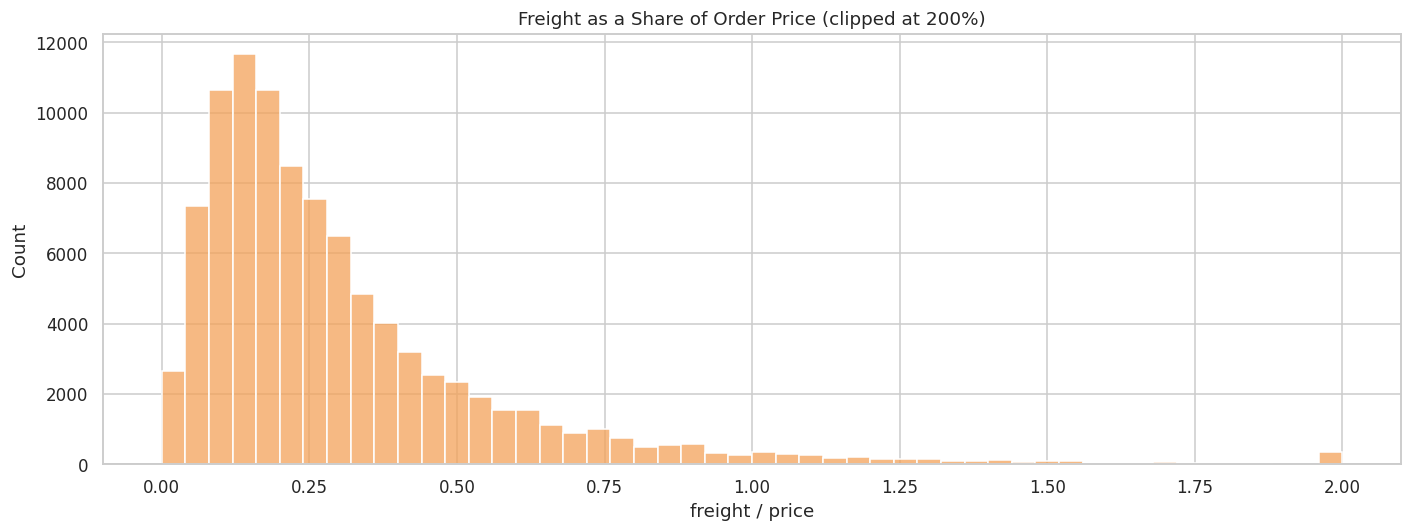

       item_price_total  freight_total  freight_ratio
count         96,478.00      96,478.00      96,478.00
mean             137.04          22.79           0.31
std              209.05          21.56           0.31
min                0.85           0.00           0.00
25%               45.90          13.85           0.13
50%               86.57          17.17           0.22
75%              149.90          24.02           0.38
max           13,440.00       1,794.96          21.45


In [ ]:
delivered["freight_ratio"] = delivered["freight_total"] / delivered["item_price_total"].replace(0, np.nan)
fig, ax = plt.subplots(figsize=(13,5))
sns.histplot(delivered["freight_ratio"].clip(upper=2), bins=50, ax=ax, color="#F4A259")
ax.set_title("Freight as a Share of Order Price (clipped at 200%)")
ax.set_xlabel("freight / price")
plt.tight_layout()
plt.show()

print(delivered[["item_price_total", "freight_total", "freight_ratio"]].describe())

# Correlation Analysis

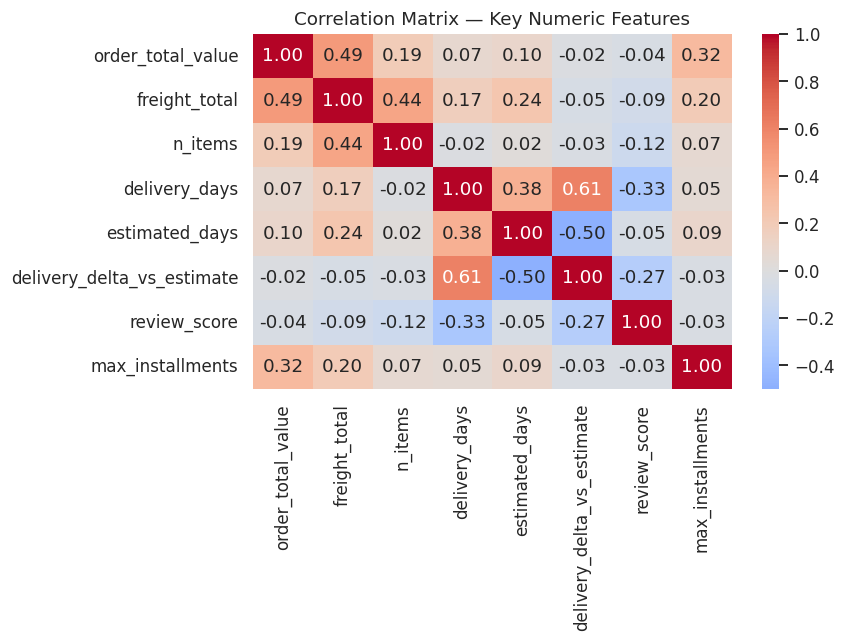

In [ ]:
num_cols = ["order_total_value", "freight_total", "n_items", "delivery_days",
            "estimated_days", "delivery_delta_vs_estimate", "review_score",
            "max_installments"]
corr_df = delivered[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Key Numeric Features")
plt.tight_layout()
plt.show()

# Candidate Problem 1: Freight Overcharge & Logistics Cost Anomaly Detection

**Summary:** Predict the expected freight cost given the true geographic distance and shipment characteristics, then flag shipments where the actual freight charge deviates abnormally from that expectation — a cost-anomaly / overcharge-detection framing rather than a generic "predict the label" exercise.

**Stakeholder:** Finance/Logistics Cost Analyst (or a category manager negotiating carrier/seller freight terms). Used to audit which sellers, routes, or product types are systematically over- or under-charging freight relative to distance and weight, informing carrier renegotiation or seller freight-policy caps.

**Regression:** Predicted freight_value per item, using engineered haversine distance between customer and seller zip-code centroids (via geolocation, aggregating lat/long by zip prefix), product weight/dimensions, and category.

**Classification:** freight_anomaly = 1 if actual freight_value falls outside a data-driven band around the regression's predicted value (e.g., residual beyond the 95th percentile, or a robust z-score on log-residuals) — i.e., the classifier is literally built on top of the regression's error distribution.

## Validate Geolocation Data

Rows dropped as out-of-bounds coordinates: 42 rows (0.0042%)

Within-prefix coordinate spread (degrees) — should mostly be small:
        lat_std   lng_std
count 19,010.00 19,010.00
mean       0.03      0.03
std        0.38      0.30
min        0.00      0.00
25%        0.00      0.00
50%        0.00      0.00
75%        0.01      0.01
max       17.45     11.36


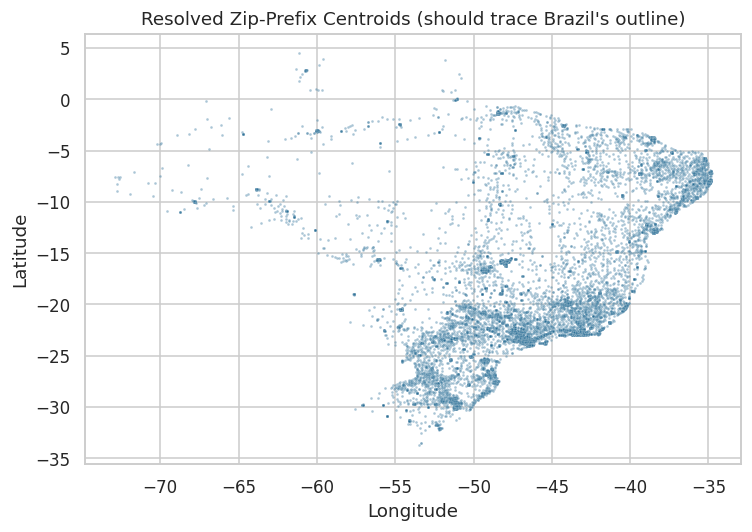

In [ ]:
# Brazil's bounding box
BR_LAT_MIN, BR_LAT_MAX = -34.0, 5.5
BR_LON_MIN, BR_LON_MAX = -74.0, -34.0

# Drop rows outside of Brazil's geolocation
geo_clean = geolocation[
    geolocation.geolocation_lat.between(BR_LAT_MIN, BR_LAT_MAX) &
    geolocation.geolocation_lng.between(BR_LON_MIN, BR_LON_MAX)
].copy()
pct_dropped = (1 - geo_clean.shape[0] / geolocation.shape[0]) * 100
print(f"Rows dropped as out-of-bounds coordinates: {geolocation.shape[0] - geo_clean.shape[0]} rows ({pct_dropped:.4f}%)")

# Filter clean data -> Take median (robust to outliers) as centroids
geo_centroids = (geo_clean.groupby("geolocation_zip_code_prefix")
                  .agg(lat=("geolocation_lat", "median"),
                       lng=("geolocation_lng", "median"),
                       n_points=("geolocation_lat", "count"))
                  .reset_index()
                  .rename(columns={"geolocation_zip_code_prefix": "zip_code_prefix"}))

# Sanity check: spread of points within a zip prefix
spread_check = (geo_clean.groupby("geolocation_zip_code_prefix")
                 .agg(lat_std=("geolocation_lat", "std"), lng_std=("geolocation_lng", "std"))
                 .fillna(0))
print("\nWithin-prefix coordinate spread (degrees) — should mostly be small:")
print(spread_check.describe())

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=geo_centroids["lng"], y=geo_centroids["lat"], s=3, alpha=0.4, ax=ax, color="#2A6F97")
ax.set_title("Resolved Zip-Prefix Centroids (should trace Brazil's outline)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Compute Seller-Customer Distance Per Order Item

Share of order-items with BOTH seller and customer coordinates resolved: 99.5%


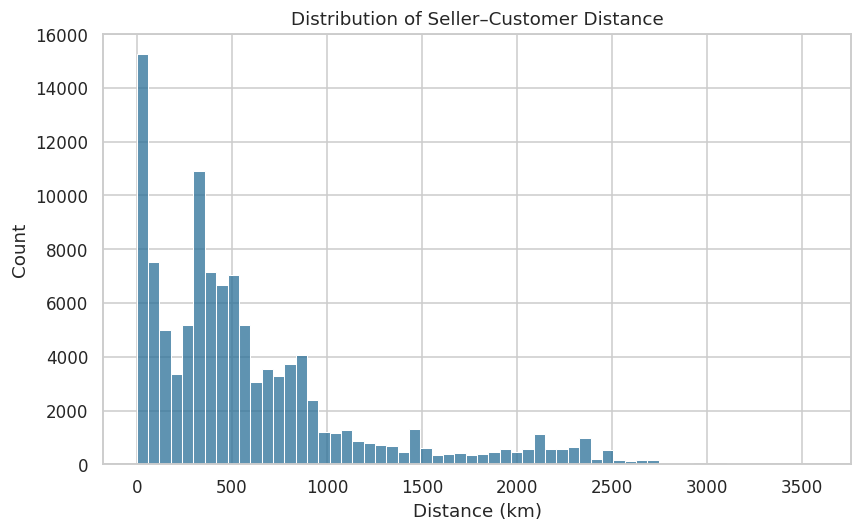

count   112,095.00
mean        596.65
std         588.84
min           0.00
25%         183.09
50%         431.71
75%         791.78
max       3,579.34
Name: distance_km, dtype: float64
Share of items shipped WITHIN the same state: 36.3%


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

seller_geo = (sellers.merge(geo_centroids, left_on="seller_zip_code_prefix",
                             right_on="zip_code_prefix", how="left")
              .rename(columns={"lat": "seller_lat", "lng": "seller_lng"})
              [["seller_id", "seller_lat", "seller_lng", "seller_state"]])

cust_geo = (customers.merge(geo_centroids, left_on="customer_zip_code_prefix",
                             right_on="zip_code_prefix", how="left")
            .rename(columns={"lat": "cust_lat", "lng": "cust_lng"})
            [["customer_id", "cust_lat", "cust_lng", "customer_state"]])

df = (items.merge(orders[["order_id", "customer_id", "order_status"]], on="order_id", how="left")
      .merge(seller_geo, on="seller_id", how="left")
      .merge(cust_geo, on="customer_id", how="left"))

geo_coverage = df[["seller_lat", "cust_lat"]].notna().all(axis=1).mean() * 100
print(f"Share of order-items with BOTH seller and customer coordinates resolved: {geo_coverage:.1f}%")

df = df.dropna(subset=["seller_lat", "seller_lng", "cust_lat", "cust_lng"]).copy()
df["distance_km"] = haversine_km(df.seller_lat, df.seller_lng, df.cust_lat, df.cust_lng)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["distance_km"].clip(upper=4000), bins=60, ax=ax, color="#2A6F97")
ax.set_title("Distribution of Seller–Customer Distance")
ax.set_xlabel("Distance (km)")
plt.tight_layout()
plt.show()

print(df["distance_km"].describe())
same_state_pct = (df.seller_state == df.customer_state).mean() * 100
print(f"Share of items shipped WITHIN the same state: {same_state_pct:.1f}%")

## Freight vs Distance / Weight

Rows usable for freight-signal check: 111,687 of 112,095


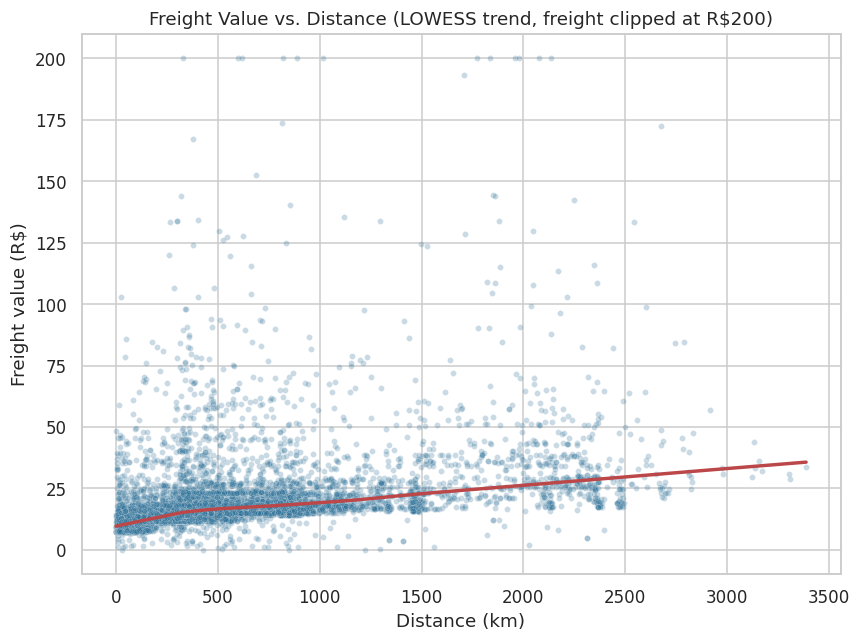

Pearson correlation (distance, freight_value): r=0.392, p=0.00e+00


In [ ]:
# ATTACH PRODUCT WEIGHT & CATEGORY DATA
products_en = products.merge(cat_trans, on="product_category_name", how="left")
products_en["category_en"] = products_en["product_category_name_english"].fillna(
    products_en["product_category_name"])

df = df.merge(products_en[["product_id", "product_weight_g", "category_en"]],
               on="product_id", how="left")

# Drop rows with missing weight/freight for the core signal check
core = df.dropna(subset=["freight_value", "distance_km", "product_weight_g"]).copy()
core = core[(core.freight_value > 0) & (core.product_weight_g > 0)]
print(f"Rows usable for freight-signal check: {core.shape[0]:,} of {df.shape[0]:,}")

# FREIGHT vs DISTANCE SCATTER
sample = core.sample(min(8000, len(core)), random_state=42)  # sample for plot legibility

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=sample["distance_km"], y=sample["freight_value"].clip(upper=200),
                 alpha=0.25, s=15, ax=ax, color="#2A6F97")
sns.regplot(x=sample["distance_km"], y=sample["freight_value"].clip(upper=200),
            scatter=False, ax=ax, color="#BC4749", lowess=True)
ax.set_title("Freight Value vs. Distance (LOWESS trend, freight clipped at R$200)")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Freight value (R$)")
plt.tight_layout()
plt.show()

r_dist, p_dist = pearsonr(core["distance_km"], core["freight_value"])
print(f"Pearson correlation (distance, freight_value): r={r_dist:.3f}, p={p_dist:.2e}")

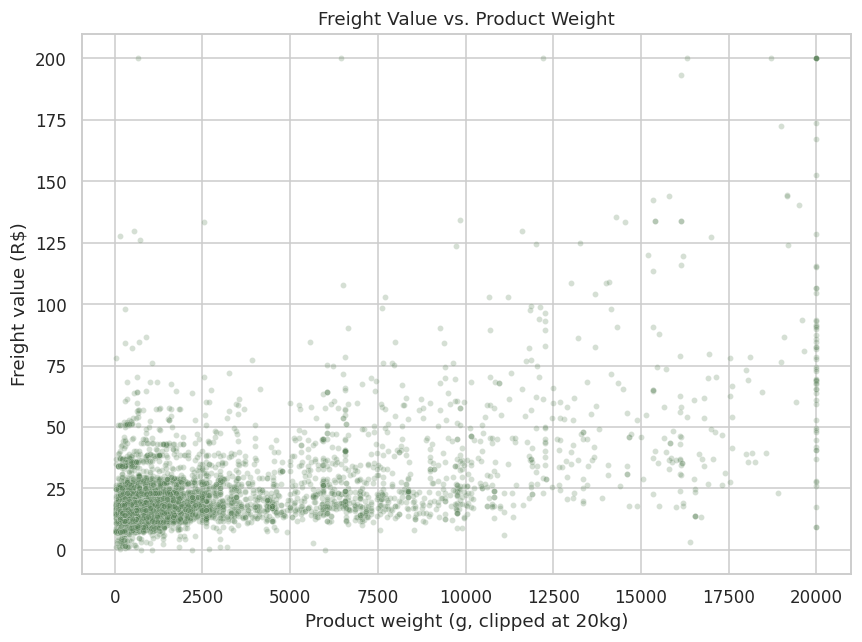

Pearson correlation (weight, freight_value): r=0.613, p=0.00e+00


In [ ]:
# FREIGHT vs WEIGHT SCATTER
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=sample["product_weight_g"].clip(upper=20000),
                 y=sample["freight_value"].clip(upper=200),
                 alpha=0.25, s=15, ax=ax, color="#588157")
ax.set_title("Freight Value vs. Product Weight")
ax.set_xlabel("Product weight (g, clipped at 20kg)")
ax.set_ylabel("Freight value (R$)")
plt.tight_layout()
plt.show()

r_wt, p_wt = pearsonr(core["product_weight_g"], core["freight_value"])
print(f"Pearson correlation (weight, freight_value): r={r_wt:.3f}, p={p_wt:.2e}")

/tmp/ipykernel_27073/3129456695.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = core.pivot_table(values="freight_value", index="weight_bucket",


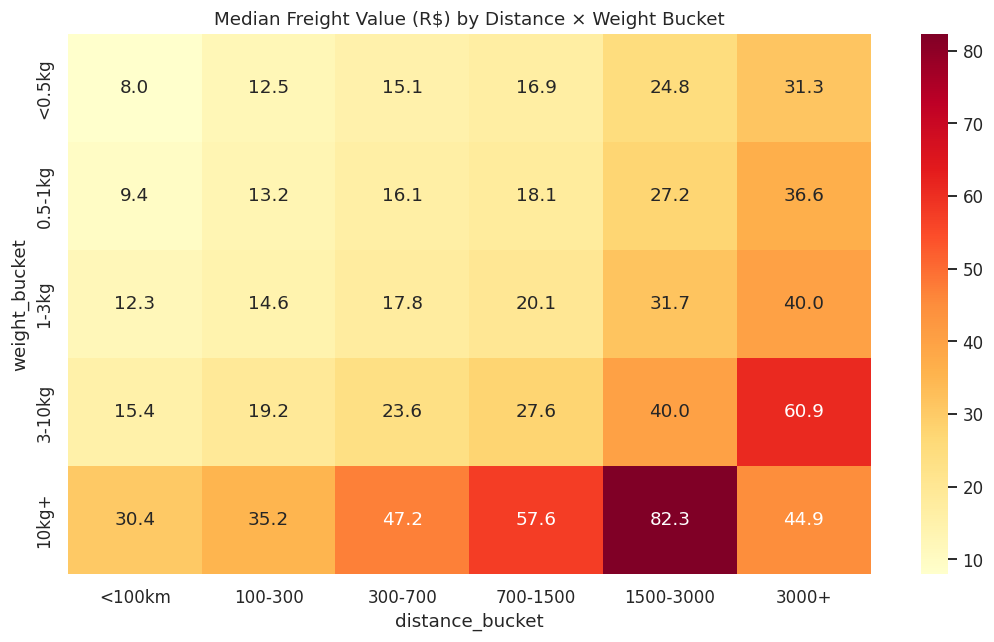

In [ ]:
# JOINT VIEW — distance BUCKETS x weight BUCKETS
core["distance_bucket"] = pd.cut(core["distance_km"],
                                  bins=[0, 100, 300, 700, 1500, 3000, 10000],
                                  labels=["<100km", "100-300", "300-700", "700-1500", "1500-3000", "3000+"])
core["weight_bucket"] = pd.cut(core["product_weight_g"],
                                bins=[0, 500, 1000, 3000, 10000, 100000],
                                labels=["<0.5kg", "0.5-1kg", "1-3kg", "3-10kg", "10kg+"])

pivot = core.pivot_table(values="freight_value", index="weight_bucket",
                          columns="distance_bucket", aggfunc="median")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Median Freight Value (R$) by Distance × Weight Bucket")
plt.tight_layout()
plt.show()

## Baseline Regression and Residual

Baseline (distance + weight only) — MAE: 7.05  R²: 0.321
Naive median-only baseline   — MAE: 7.76


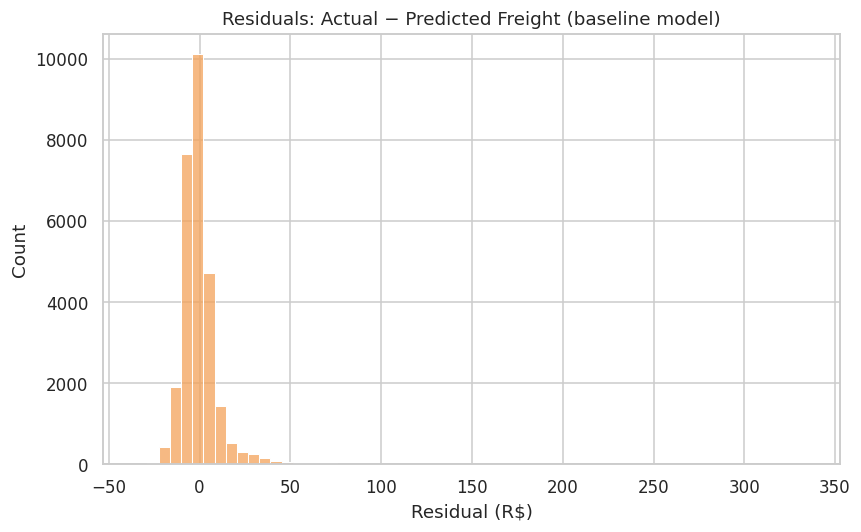


Using a 5th/95th percentile band as a candidate anomaly threshold:
  Overcharge candidates (residual > 16.40): 1,397 items
  Undercharge candidates (residual < -12.24): 1,397 items

Sample of highest-residual (likely overcharged) items:
       distance_km  product_weight_g  freight_value  predicted_freight  \
27898       449.54         30,000.00         375.28              40.79   
69435       617.28         25,250.00         339.59              41.08   
3561        241.53         30,000.00         321.46              38.42   
87484       433.05         30,000.00         322.10              40.65   
90864     2,133.70         18,700.00         299.16              44.22   

       residual                      category_en  
27898    334.49                       housewares  
69435    298.51                       housewares  
3561     283.04  construction_tools_construction  
87484    281.45                    health_beauty  
90864    254.94           signaling_and_security  


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

model_df = core.copy()
model_df["log_distance"] = np.log1p(model_df["distance_km"])
model_df["log_weight"] = np.log1p(model_df["product_weight_g"])

X = model_df[["log_distance", "log_weight"]]
y = model_df["freight_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

baseline = LinearRegression().fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print(f"Baseline (distance + weight only) — MAE: {mean_absolute_error(y_test, y_pred):.2f}  "
      f"R²: {r2_score(y_test, y_pred):.3f}")

# Naive flat-rate baseline for comparison (median freight, no features)
naive_pred = np.full_like(y_test, y_train.median(), dtype=float)
print(f"Naive median-only baseline   — MAE: {mean_absolute_error(y_test, naive_pred):.2f}")

model_df.loc[X_test.index, "predicted_freight"] = y_pred
model_df.loc[X_test.index, "residual"] = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(model_df["residual"].dropna(), bins=60, ax=ax, color="#F4A259")
ax.set_title("Residuals: Actual − Predicted Freight (baseline model)")
ax.set_xlabel("Residual (R$)")
plt.tight_layout()
plt.show()

resid = model_df["residual"].dropna()
p95, p05 = resid.quantile(0.95), resid.quantile(0.05)
n_anomaly_high = (resid > p95).sum()
n_anomaly_low = (resid < p05).sum()
print(f"\nUsing a 5th/95th percentile band as a candidate anomaly threshold:")
print(f"  Overcharge candidates (residual > {p95:.2f}): {n_anomaly_high:,} items")
print(f"  Undercharge candidates (residual < {p05:.2f}): {n_anomaly_low:,} items")

# Spot-check a few of the largest positive residuals
print("\nSample of highest-residual (likely overcharged) items:")
print(model_df.loc[X_test.index].nlargest(5, "residual")
      [["distance_km", "product_weight_g", "freight_value", "predicted_freight", "residual", "category_en"]])

## Freight Patterns by Category and Seller

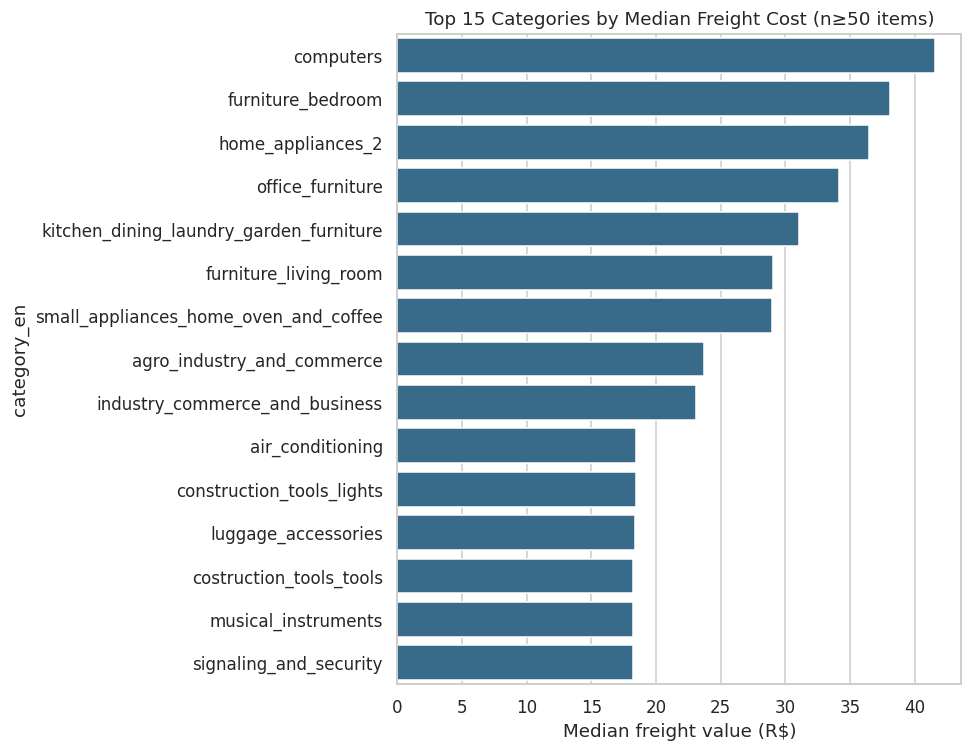

In [ ]:
cat_freight = (core.groupby("category_en")
               .agg(median_freight=("freight_value", "median"),
                    median_distance=("distance_km", "median"),
                    n=("freight_value", "count"))
               .query("n >= 50")
               .sort_values("median_freight", ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=cat_freight["median_freight"], y=cat_freight.index, ax=ax, color="#2A6F97")
ax.set_xlabel("Median freight value (R$)")
ax.set_title("Top 15 Categories by Median Freight Cost (n≥50 items)")
plt.tight_layout()
plt.show()

In [ ]:
seller_resid = (model_df.dropna(subset=["residual"])
                 .groupby("seller_id")
                 .agg(mean_residual=("residual", "mean"), n_items=("residual", "count"))
                 .query("n_items >= 20")
                 .sort_values("mean_residual", ascending=False))
print(f"\nSellers with ≥20 items in test set: {seller_resid.shape[0]}")
print("Top 5 sellers by average positive residual (candidate systematic over-chargers):")
print(seller_resid.head(5))
print("Bottom 5 sellers by average residual (candidate systematic under-chargers):")
print(seller_resid.tail(5))


Sellers with ≥20 items in test set: 320
Top 5 sellers by average positive residual (candidate systematic over-chargers):
                                  mean_residual  n_items
seller_id                                               
712e6ed8aa4aa1fa65dab41fed5737e4          31.59       20
17a053fcb14bd219540cbde0df490be0          24.48       43
76d64c4aca3a7baf218bf93ef7fa768d          14.92       20
06e5eefc71ec47ae763c5c6f8db7064f          14.73       23
f5a590cf36251cf1162ea35bef76fe84          13.13       25
Bottom 5 sellers by average residual (candidate systematic under-chargers):
                                  mean_residual  n_items
seller_id                                               
6fc26fe110feebd80a433e1f012a84f9          -8.59       20
7142540dd4c91e2237acb7e911c4eba2          -9.18       90
1d8dbc4f32378d715c717c1c1fc57bae          -9.92       22
1a3df491d1c4f1589fc2b934ada68bf2          -9.99       55
813348c996469b40f2e028d5429d3495         -10.38       57


# Candidate Problem 2: Seller Marketplace Health Scoring

**Problem:** Build a seller-month panel (one row per seller per month of activity) and predict forward-looking seller health, which forces you to handle temporal train/test splitting correctly and engineer trailing-window features rather than static ones.

**Stakeholder:** Marketplace/Seller Operations Manager. Used to proactively flag sellers whose performance is deteriorating — before it shows up in aggregate platform-wide review scores — for account-manager outreach, catalog audits, or removal from a "featured seller" program.

**Classification:** seller_at_risk = 1 if, in month t+1, the seller's average review score drops below a threshold (e.g., <3.5) or their late-delivery rate exceeds a threshold, relative to their own trailing baseline (so it captures deterioration, not just "small sellers are always bad").

**Regression:** Predicted seller revenue for month t+1 (or predicted average review score as a continuous target), letting Ops forecast near-term seller-driven GMV and prioritize larger-revenue sellers who are also at risk.

In [ ]:
MIN_ACTIVE_MONTHS = 3   # minimum months of activity for a seller to enter the panel
AT_RISK_REVIEW_THRESHOLD = 3.5
AT_RISK_LATE_RATE_THRESHOLD = 0.15

In [ ]:
orders_d = orders[orders.order_status == "delivered"].copy()
orders_d["delivery_days"] = (orders_d["order_delivered_customer_date"]
                              - orders_d["order_purchase_timestamp"]).dt.days
orders_d["is_late"] = (orders_d["order_delivered_customer_date"]
                        > orders_d["order_estimated_delivery_date"])
orders_d["purchase_month"] = orders_d["order_purchase_timestamp"].dt.to_period("M")

review_dedup = (reviews.sort_values("review_creation_date")
                .drop_duplicates("order_id", keep="last")
                [["order_id", "review_score"]])

base = (items.merge(orders_d[["order_id", "purchase_month", "is_late", "delivery_days"]],
                     on="order_id", how="inner")   # inner: only delivered orders
        .merge(review_dedup, on="order_id", how="left"))

print(f"Order-item rows in base table (delivered orders only): {base.shape[0]:,}")
print(f"Distinct sellers represented: {base['seller_id'].nunique():,}")

Order-item rows in base table (delivered orders only): 110,197
Distinct sellers represented: 2,970


## SELLER TENURE CHECK — do sellers have enough months for a panel?

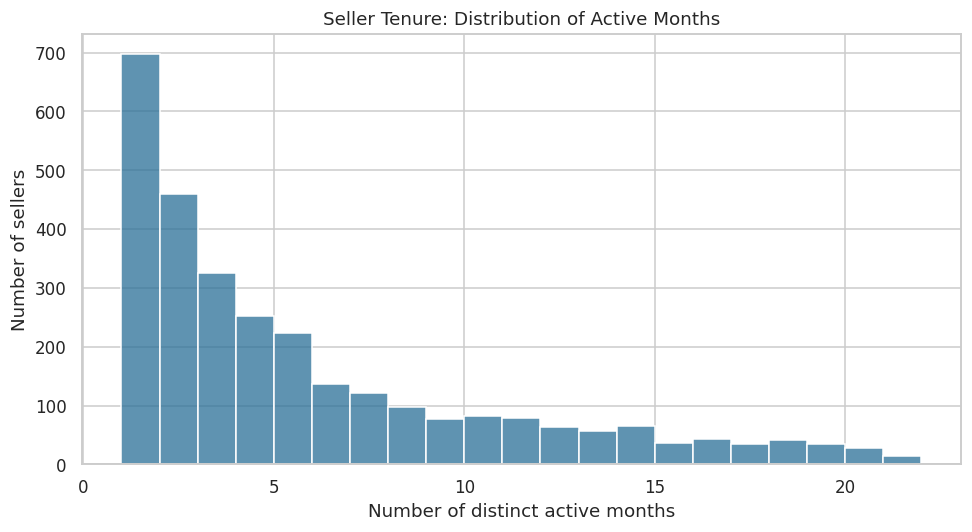

count   2,970.00
mean        5.41
std         4.99
min         1.00
25%         2.00
50%         4.00
75%         8.00
max        21.00
Name: n_active_months, dtype: float64

Share of sellers with FEWER than 3 active months (too short for meaningful panel/trailing features): 38.9%
Sellers eligible for the panel (≥3 active months): 1,814 of 2,970 (61.1%)


In [ ]:
seller_months = (base.groupby("seller_id")["purchase_month"]
                  .nunique().rename("n_active_months").reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(seller_months["n_active_months"], bins=range(1, seller_months["n_active_months"].max()+2),
             ax=ax, color="#2A6F97")
ax.set_xlabel("Number of distinct active months")
ax.set_ylabel("Number of sellers")
ax.set_title("Seller Tenure: Distribution of Active Months")
plt.tight_layout()
plt.show()

print(seller_months["n_active_months"].describe())
pct_short_tenure = (seller_months["n_active_months"] < MIN_ACTIVE_MONTHS).mean() * 100
print(f"\nShare of sellers with FEWER than {MIN_ACTIVE_MONTHS} active months "
      f"(too short for meaningful panel/trailing features): {pct_short_tenure:.1f}%")

eligible_sellers = seller_months[seller_months.n_active_months >= MIN_ACTIVE_MONTHS]["seller_id"]
print(f"Sellers eligible for the panel (≥{MIN_ACTIVE_MONTHS} active months): "
      f"{len(eligible_sellers):,} of {seller_months.shape[0]:,} ({len(eligible_sellers)/seller_months.shape[0]*100:.1f}%)")

## BUILD THE SELLER-MONTH PANEL

In [ ]:
panel_base = base[base.seller_id.isin(eligible_sellers)].copy()

items_price = items[["order_id", "order_item_id", "price", "freight_value"]]
panel_base = panel_base.merge(items_price, on=["order_id", "order_item_id"],
                               how="left", suffixes=("", "_dup"))

panel = (panel_base.groupby(["seller_id", "purchase_month"])
         .agg(revenue=("price", "sum"),
              n_orders=("order_id", "nunique"),
              n_items=("order_item_id", "count"),
              avg_review_score=("review_score", "mean"),
              late_rate=("is_late", "mean"),
              avg_delivery_days=("delivery_days", "mean"),
              avg_freight=("freight_value", "mean"))
         .reset_index())

panel["purchase_month"] = panel["purchase_month"].dt.to_timestamp()
panel = panel.sort_values(["seller_id", "purchase_month"])

print(f"Panel shape (seller-month rows): {panel.shape}")
panel.head(10)

Panel shape (seller-month rows): (14453, 9)


,seller_id,purchase_month,revenue,n_orders,n_items,avg_review_score,late_rate,avg_delivery_days,avg_freight
0,001cca7ae9ae17fb1caed9dfb1094831,2017-02-01,"1,098.90",5,11,4.27,0.00,11.73,17.86
1,001cca7ae9ae17fb1caed9dfb1094831,2017-03-01,"1,676.70",11,17,3.12,0.06,12.29,26.31
2,001cca7ae9ae17fb1caed9dfb1094831,2017-04-01,"1,708.20",13,15,3.87,0.07,11.07,25.29
3,001cca7ae9ae17fb1caed9dfb1094831,2017-05-01,"2,639.99",23,26,3.84,0.00,8.27,37.58
4,001cca7ae9ae17fb1caed9dfb1094831,2017-06-01,"2,213.49",21,22,4.41,0.05,10.91,34.85
5,001cca7ae9ae17fb1caed9dfb1094831,2017-07-01,"2,483.95",21,25,4.17,0.04,12.24,42.08
6,001cca7ae9ae17fb1caed9dfb1094831,2017-08-01,"1,244.00",11,12,4.08,0.00,10.33,38.80
7,001cca7ae9ae17fb1caed9dfb1094831,2017-09-01,"1,714.00",12,16,4.12,0.00,11.75,40.08
8,001cca7ae9ae17fb1caed9dfb1094831,2017-10-01,"2,626.00",22,25,3.88,0.08,12.36,39.99
9,001cca7ae9ae17fb1caed9dfb1094831,2017-11-01,"2,540.00",20,25,4.08,0.12,15.80,36.98


## PERSISTENCE / AUTOCORRELATION CHECK — the core "is this forecastable" test

Seller-month rows with a valid prior-month lag: 12,623


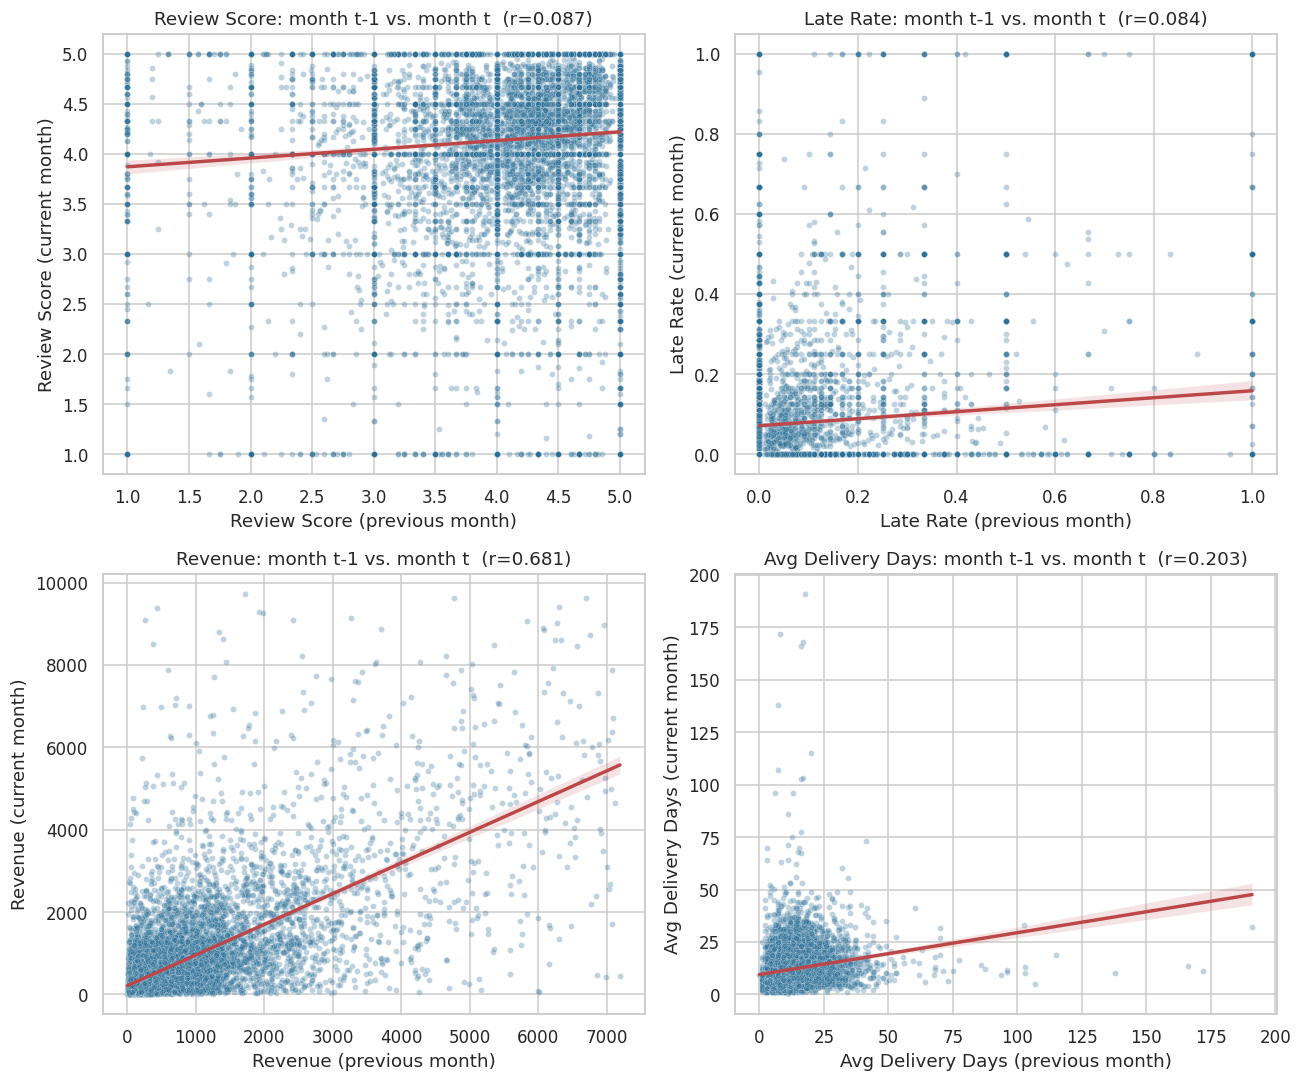


Month-over-month autocorrelation summary:
  Review Score         r = 0.087
  Late Rate            r = 0.084
  Revenue              r = 0.785
  Avg Delivery Days    r = 0.203


In [ ]:
panel["month_rank"] = panel.groupby("seller_id").cumcount()

lag_cols = ["avg_review_score", "late_rate", "revenue", "avg_delivery_days"]
panel_lagged = panel.copy()
for col in lag_cols:
    panel_lagged[f"{col}_prev"] = panel_lagged.groupby("seller_id")[col].shift(1)

# Only rows where a previous month exists (i.e., consecutive OR any prior
# panel row for that seller — using shift(1) on the seller's own sorted
# sequence, so "prev" = seller's immediately preceding active month, not
# necessarily the calendar-adjacent month; note this in the report as a
# simplification for sellers with gaps)
lag_valid = panel_lagged.dropna(subset=[f"{c}_prev" for c in lag_cols])
print(f"Seller-month rows with a valid prior-month lag: {lag_valid.shape[0]:,}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [("avg_review_score_prev", "avg_review_score", "Review Score"),
         ("late_rate_prev", "late_rate", "Late Rate"),
         ("revenue_prev", "revenue", "Revenue"),
         ("avg_delivery_days_prev", "avg_delivery_days", "Avg Delivery Days")]

for ax, (prev_col, curr_col, label) in zip(axes.flat, pairs):
    plot_df = lag_valid[[prev_col, curr_col]].dropna()
    if label == "Revenue":
        plot_df = plot_df[plot_df[curr_col] < plot_df[curr_col].quantile(0.99)]
        plot_df = plot_df[plot_df[prev_col] < plot_df[prev_col].quantile(0.99)]
    r = plot_df[prev_col].corr(plot_df[curr_col])
    sns.scatterplot(x=plot_df[prev_col], y=plot_df[curr_col], alpha=0.3, s=15, ax=ax, color="#2A6F97")
    sns.regplot(x=plot_df[prev_col], y=plot_df[curr_col], scatter=False, ax=ax, color="#BC4749")
    ax.set_title(f"{label}: month t-1 vs. month t  (r={r:.3f})")
    ax.set_xlabel(f"{label} (previous month)")
    ax.set_ylabel(f"{label} (current month)")

plt.tight_layout()
plt.show()

autocorr_summary = {label: lag_valid[prev_col].corr(lag_valid[curr_col])
                     for prev_col, curr_col, label in pairs}
print("\nMonth-over-month autocorrelation summary:")
for k, v in autocorr_summary.items():
    print(f"  {k:20s} r = {v:.3f}")

In [ ]:
lag_valid_volume = lag_valid.merge(
    panel[["seller_id", "purchase_month", "n_orders"]],
    on=["seller_id", "purchase_month"], how="left")

for min_orders in [1, 3, 5, 10]:
    subset = lag_valid_volume[lag_valid_volume["n_orders_x"] >= min_orders]
    if len(subset) > 30:
        r = subset["avg_review_score_prev"].corr(subset["avg_review_score"])
        print(f"Min {min_orders:>2} orders/month → n={len(subset):>5}  "
              f"review-score autocorrelation r={r:.3f}")

Min  1 orders/month → n=12623  review-score autocorrelation r=0.087
Min  3 orders/month → n= 7112  review-score autocorrelation r=0.114
Min  5 orders/month → n= 4663  review-score autocorrelation r=0.168
Min 10 orders/month → n= 2280  review-score autocorrelation r=0.275


## AT-RISK LABEL FEASIBILITY (imbalance + definition check)

Share of seller-month rows flagged 'at_risk' (review<3.5 or late_rate>0.15): 25.5%


/tmp/ipykernel_27073/2713993286.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy", "At risk"])


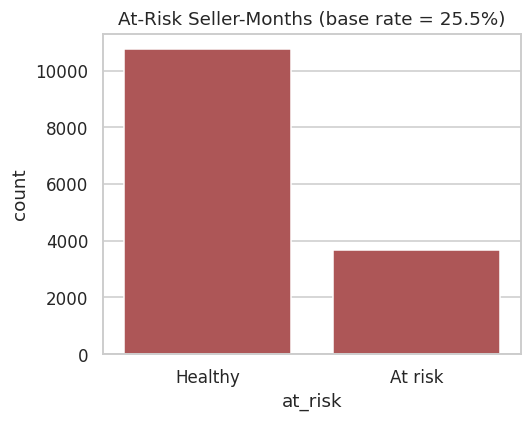

In [ ]:
panel_lagged["at_risk"] = (
    (panel_lagged["avg_review_score"] < AT_RISK_REVIEW_THRESHOLD) |
    (panel_lagged["late_rate"] > AT_RISK_LATE_RATE_THRESHOLD)
).astype(int)

at_risk_rate = panel_lagged["at_risk"].mean() * 100
print(f"Share of seller-month rows flagged 'at_risk' "
      f"(review<{AT_RISK_REVIEW_THRESHOLD} or late_rate>{AT_RISK_LATE_RATE_THRESHOLD}): {at_risk_rate:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="at_risk", data=panel_lagged, ax=ax, color="#BC4749")
ax.set_xticklabels(["Healthy", "At risk"])
ax.set_title(f"At-Risk Seller-Months (base rate = {at_risk_rate:.1f}%)")
plt.tight_layout()
plt.show()

In [ ]:
# Does PRIOR month's at-risk status predict CURRENT month's at-risk status?
# (the deterioration framing depends on there being room to move — check
# that at-risk isn't just a fixed trait some sellers always have)
panel_lagged["at_risk_prev"] = (
    (panel_lagged["avg_review_score_prev"] < AT_RISK_REVIEW_THRESHOLD) |
    (panel_lagged["late_rate_prev"] > AT_RISK_LATE_RATE_THRESHOLD)
).astype(int)

transition = pd.crosstab(panel_lagged["at_risk_prev"], panel_lagged["at_risk"],
                          normalize="index").mul(100).round(1)
transition.index = ["Prev: Healthy", "Prev: At risk"]
transition.columns = ["Now: Healthy", "Now: At risk"]
print("\nAt-risk state transition matrix (row = prior month, % of row):")
print(transition)


At-risk state transition matrix (row = prior month, % of row):
               Now: Healthy  Now: At risk
Prev: Healthy         76.50         23.50
Prev: At risk         67.40         32.60


## REVENUE FORECASTING BASELINE PREVIEW (regression target feasibility)

In [ ]:
from sklearn.metrics import mean_absolute_error

rev_valid = lag_valid.dropna(subset=["revenue_prev", "revenue"])
naive_mae = mean_absolute_error(rev_valid["revenue"], rev_valid["revenue_prev"])
mean_mae = mean_absolute_error(rev_valid["revenue"], np.full(len(rev_valid), rev_valid["revenue"].mean()))

print(f"Naive persistence baseline (predict t = t-1) MAE: {naive_mae:,.2f}")
print(f"Naive mean-only baseline                     MAE: {mean_mae:,.2f}")
print(f"Persistence beats mean-only by: {(1 - naive_mae/mean_mae)*100:.1f}%")


Naive persistence baseline (predict t = t-1) MAE: 559.06
Naive mean-only baseline                     MAE: 965.40
Persistence beats mean-only by: 42.1%


## Summary Table

In [ ]:
"""
SUGGESTED GO/NO-GO SUMMARY TO FILL IN AFTER RUNNING
------------------------------------------------------------------------
| Check                                   | Result | Pass bar                         |
|-----------------------------------------|--------|----------------------------------|
| % sellers with ≥3 active months         |  61%   | ideally >30-40% of seller base   |
| Review-score month-over-month r         | 0.087  | meaningfully > 0 (e.g. >0.15-0.2)|
| Late-rate month-over-month r            | 0.084  | meaningfully > 0                 |
| Revenue month-over-month r              | 0.681  | strong, expected high            |
| At-risk base rate                       | 25.5%  | minority, not <2% or >50%        |
| Healthy→At-risk transition %            | 23.5%  | non-trivial (not near 0%)        |
| Persistence baseline beats mean baseline| 42.1%  | should clearly beat it           |
---------------------------------------------------------------------------------------
If review-score/late-rate persistence is weak AND the transition matrix looks static, recommend redefining at-risk as a relative
(within-seller) deterioration measure before finalizing scope, per the note in section 6.
"""

'\nSUGGESTED GO/NO-GO SUMMARY TO FILL IN AFTER RUNNING\n------------------------------------------------------------------------\n| Check                                   | Result | Pass bar                        |\n|------------------------------------------|--------|----------------------------------|\n| % sellers with ≥3 active months           |        | ideally >30-40% of seller base   |\n| Review-score month-over-month r           |        | meaningfully > 0 (e.g. >0.15-0.2)|\n| Late-rate month-over-month r              |        | meaningfully > 0                |\n| Revenue month-over-month r                |        | strong, expected high            |\n| At-risk base rate                         |        | minority, not <2% or >50%        |\n| Healthy→At-risk transition %              |        | non-trivial (not near 0%)        |\n| Persistence baseline beats mean baseline  |        | should clearly beat it           |\n--------------------------------------------------------